# Exercício 3 - Classificação

Aluno: Fabio Kishino

### Parte 1 - Classificação

1- Utilize o dataset “titanic.csv”, disponível no moodle. Considere 70% das instâncias para treino e 30% para validação. Construa um modelo utilizando Árvore de Decisão para prever se uma pessoa sobreviveu ou não.<br>

* a) Mostre a árvore encontrada.
* b) Qual a acurácia do modelo obtida com os dados de validação?

In [1]:
import seaborn as sns

df = sns.load_dataset("titanic")

# A feature 'alive' foi removida, pois é redundante com 'survived' e afeta o modelo
df.drop(['age', 'embarked', 'deck', 'embark_town', 'alive'], axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

categorical_columns = ['sex', 'class', 'who']
for col in categorical_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col]).astype('int8')

df_encoded.info()
df_encoded.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    int8   
 3   sibsp       891 non-null    int64  
 4   parch       891 non-null    int64  
 5   fare        891 non-null    float64
 6   class       891 non-null    int8   
 7   who         891 non-null    int8   
 8   adult_male  891 non-null    bool   
 9   alone       891 non-null    bool   
dtypes: bool(2), float64(1), int64(4), int8(3)
memory usage: 39.3 KB


,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alone
0,0,3,1,1,0,7.2500,2,1,True,False
1,1,1,0,1,0,71.2833,0,2,False,False
2,1,3,0,0,0,7.9250,2,2,False,True
3,1,1,0,1,0,53.1000,0,2,False,False
4,0,3,1,0,0,8.0500,2,1,True,True


In [2]:
# Separação do dataset
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_encoded, test_size=0.3, random_state=42)
df_train

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alone
445,1,1,1,0,2,81.8583,0,0,False,False
650,0,3,1,0,0,7.8958,2,1,True,True
172,1,3,0,1,1,11.1333,2,0,False,False
450,0,2,1,1,2,27.7500,1,1,True,False
314,0,2,1,1,1,26.2500,1,1,True,False
...,...,...,...,...,...,...,...,...,...,...
106,1,3,0,0,0,7.6500,2,2,False,True
270,0,1,1,0,0,31.0000,0,1,True,True
860,0,3,1,2,0,14.1083,2,1,True,False
435,1,1,0,1,2,120.0000,0,0,False,False


[]

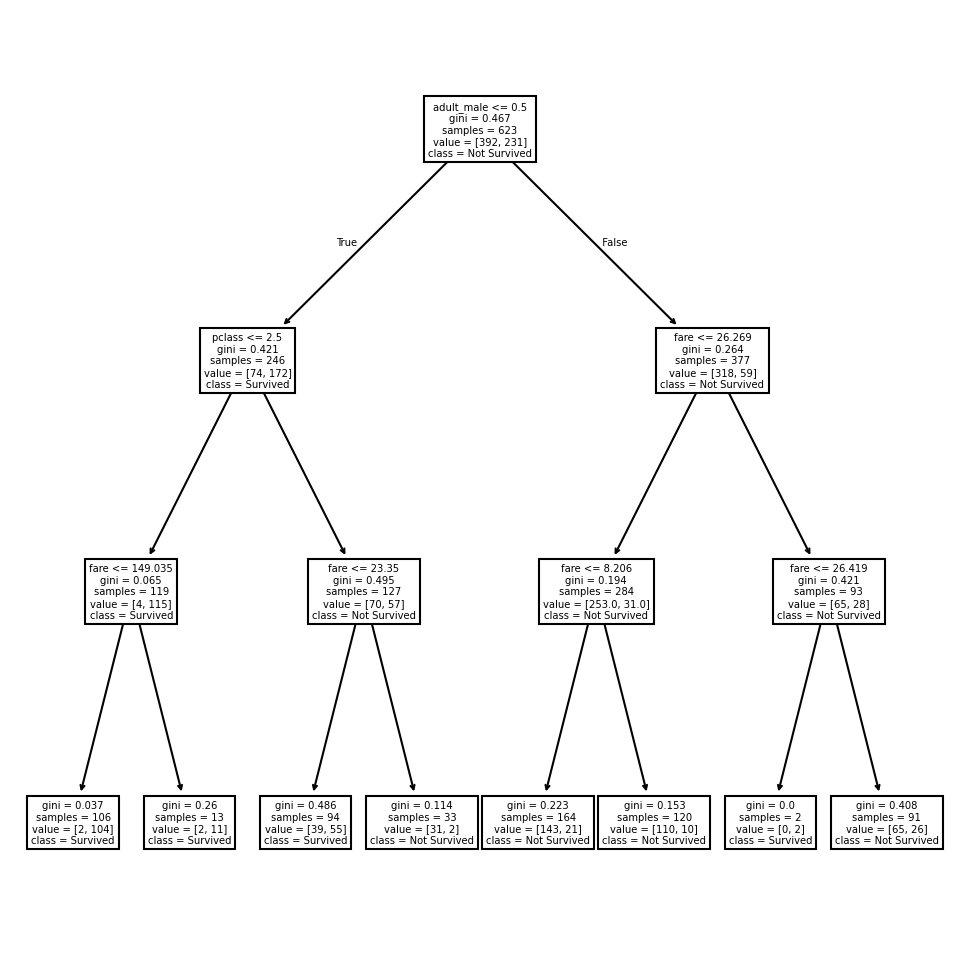

In [3]:
from sklearn import tree
import matplotlib.pyplot as plt

model = tree.DecisionTreeClassifier(max_depth=3)

# X contém apenas features, y contém o rótulo
X = df_train[['pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']]
y = df_train['survived']

model.fit(X, y)

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (8,8), dpi=150)
tree.plot_tree(model, feature_names = X.columns, class_names=['Not Survived', 'Survived']) 
plt.plot()


In [4]:
# Acurácia
X_test = df_test[["pclass", "sex", "sibsp", "parch", "fare", "class", "who", "adult_male", "alone"]]

# print(X_test)
y_test = df_test['survived']
print("Acurácia média: %.2f%%" % (model.score(X_test, y_test) * 100))

Acurácia média: 82.84%


2- Considere ainda uma árvore de decisão para classificar se um indivíduo sobreviveu ou não com base no dataset “titanic.csv”. Qual o resultado médio de acurácia utilizando a estratégia de validação cruzada 10-fold? Discuta os resultados.

In [5]:
from sklearn.model_selection import cross_val_score

X = df_train[['pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']]
y = df_train['survived']

scores = cross_val_score(model, X, y, cv=5)

tree_model = tree.DecisionTreeClassifier()

scores = cross_val_score(tree_model, X, y, cv=10)

print("Acurácia média: %.2f%%" % (scores.mean() * 100))
print("Desvio padrão: %.4f" % scores.std())

Acurácia média: 82.35%
Desvio padrão: 0.0433


3- Ainda considerando o dataset “titanic.csv”, construa um modelo utilizando k-NN para prever se uma pessoa sobreviveu ou não. Considere diferentes valores de k vizinhos: k={2,3,4,5,6,7}. Houve variação significativa nos diferentes modelos testados? Algum deles foi melhor do que a estratégia baseada em árvore de decisão?

In [6]:
# Knn
from sklearn.neighbors import KNeighborsClassifier

k_neighbors = [2,3,4,5,6,7]

for k in k_neighbors:
    neigh = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(neigh, X, y, cv=10)
    print("Acurácia média para k=%d: %.2f%%" % (k, scores.mean() * 100))
    print("Desvio padrão: %.4f \n" % scores.std())


Acurácia média para k=2: 73.52%
Desvio padrão: 0.0352 

Acurácia média para k=3: 75.93%
Desvio padrão: 0.0690 

Acurácia média para k=4: 74.32%
Desvio padrão: 0.0639 

Acurácia média para k=5: 75.77%
Desvio padrão: 0.0552 

Acurácia média para k=6: 73.51%
Desvio padrão: 0.0380 

Acurácia média para k=7: 75.61%
Desvio padrão: 0.0524 



### Parte 2 – Agrupamento

4 - Considere as Latitudes e Longitudes dos estabelecimentos do dataset fornecido para o desafio. Utilizando o DBSCAN, faça o que é pedido abaixo. <br>
- a) Agrupe os estabelecimentos que são populares. Varie os valores de eps e min_samples. Escolha uma combinação que julgue produzir um resultado interessante. Justifique a sua escolha.

In [7]:
# Code here
import pandas as pd

df_desafio = pd.read_csv('../Desafio/predict-highly-rated-venues-cda-utfpr-2024/X_trainToronto.csv')

df_desafio.head()

,business_id,name,address,postal_code,latitude,longitude,review_count,is_open,attributes,categories,hours,loc,destaque
0,vHzWmPWHN4J1hRR3W3AMQg,Salt Wine Bar,225 Ossington Ave,M6J 2Z8,43.648977,-79.420495,99,1,"{'Ambience': ""{'romantic': False, 'intimate': ...","Wine Bars, Tapas/Small Plates, Restaurants, Ba...","{'Monday': '18:0-23:0', 'Tuesday': '18:0-23:0'...","{'type': 'Point', 'coordinates': [-79.4204946,...",0
1,15to24Q-otAHmto7FzsWRg,William's Beauty Supplies,2229 Dundas Street W,M6R 1X6,43.654002,-79.452189,3,1,"{'BusinessParking': ""{'garage': False, 'street...","Beauty & Spas, Hair Salons, Barbers, Shopping,...","{'Monday': '9:0-17:0', 'Tuesday': '9:0-17:0', ...","{'type': 'Point', 'coordinates': [-79.4521893,...",1
2,8aqKdf4G4AAir8k_Kdslvg,Integra Health Centre,1320-130 King Street W,M5X 1C8,43.648493,-79.383214,18,1,"{'ByAppointmentOnly': 'True', 'AcceptsInsuranc...","Health & Medical, Medical Centers","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...","{'type': 'Point', 'coordinates': [-79.3832139,...",0
3,uxU1vr5AhhkTQ83X0bpeyg,North York General Hospital,555 Finch Avenue W,M2R 1N5,43.772453,-79.448136,3,0,{'ByAppointmentOnly': 'False'},"Health & Medical, Hospitals, Medical Centers",NaN,"{'type': 'Point', 'coordinates': [-79.4481361,...",0
4,f702hTJoqdR34Jn23C7d1A,Dr Jamie's Bike Clinic,2741 Dundas St W,M6P,43.665082,-79.460800,3,1,{'RestaurantsPriceRange2': '3'},"Automotive, Bikes, Shopping, Auto Repair, Spor...",NaN,"{'type': 'Point', 'coordinates': [-79.4607999,...",0


In [8]:
df_desafio_populares = df_desafio[df_desafio['destaque'] == 1].copy()
df_desafio_populares.dropna(inplace=True)
df_desafio_populares.reset_index(drop=True, inplace=True)
# print(df_desafio_populares.isnull().any())


In [9]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

coords = df_desafio_populares[['latitude', 'longitude']]

dbscanConfig = DBSCAN(eps=0.02, min_samples=25, metric = 'euclidean')

dbscanResults = dbscanConfig.fit_predict(coords)
print(dbscanResults)

score = silhouette_score(coords, dbscanResults)
print("Silhouette Score: %.4f" % score)


[0 0 0 ... 0 0 0]
Silhouette Score: 0.3713


- b) Agrupe os estabelecimentos que não são populares. Varie os valores de eps e min_samples. Escolha uma combinação que julgue produzir um resultado interessante. Justifique a sua escolha.

In [10]:
df_desafio_nao_populares = df_desafio[df_desafio['destaque'] == 0].copy()
df_desafio_nao_populares.dropna(inplace=True)
df_desafio_nao_populares.reset_index(drop=True, inplace=True)

In [11]:
coords_nao_populares = df_desafio_nao_populares[['latitude', 'longitude']]

dbscanConfig = DBSCAN(eps=0.02, min_samples=15, metric = 'euclidean')

dbscanResults_nao_populares = dbscanConfig.fit_predict(coords_nao_populares)
print(dbscanResults_nao_populares)

score_nao_populares = silhouette_score(coords_nao_populares, dbscanResults_nao_populares)
print("Silhouette Score: %.4f" % score_nao_populares)

[0 0 0 ... 0 0 0]
Silhouette Score: 0.5028


- c) Visualize os clusters encontrados para ambos os casos. Existe alguma tendência de concentração em determinadas partes da cidade? Faça uma breve análise dos resultados encontrados.

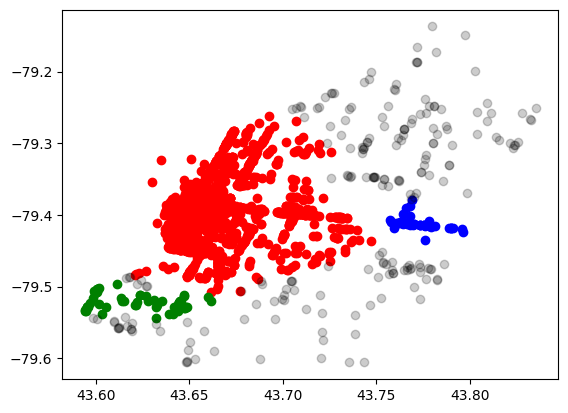

In [12]:
# Code here
plt.scatter(df_desafio_populares.loc[dbscanResults == 0,'latitude'], df_desafio_populares.loc[dbscanResults == 0,'longitude'], c = 'red')
plt.scatter(df_desafio_populares.loc[dbscanResults == 1,'latitude'], df_desafio_populares.loc[dbscanResults == 1,'longitude'], c = 'blue')
plt.scatter(df_desafio_populares.loc[dbscanResults == 2,'latitude'], df_desafio_populares.loc[dbscanResults == 2,'longitude'], c = 'green')

#Ruídos, que possuem rótulos -1, são coloridos de preto
plt.scatter(df_desafio_populares.loc[dbscanResults == -1,'latitude'], df_desafio_populares.loc[dbscanResults == -1,'longitude'], c = 'black', alpha=0.2)

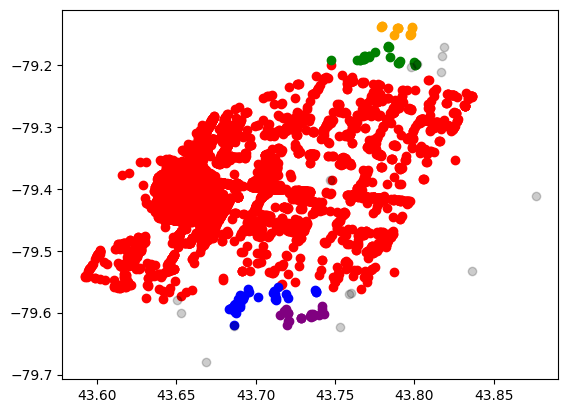

In [13]:
plt.scatter(df_desafio_nao_populares.loc[dbscanResults_nao_populares == 0,'latitude'], df_desafio_nao_populares.loc[dbscanResults_nao_populares == 0,'longitude'], c = 'red')
plt.scatter(df_desafio_nao_populares.loc[dbscanResults_nao_populares == 1,'latitude'], df_desafio_nao_populares.loc[dbscanResults_nao_populares == 1,'longitude'], c = 'blue')
plt.scatter(df_desafio_nao_populares.loc[dbscanResults_nao_populares == 2,'latitude'], df_desafio_nao_populares.loc[dbscanResults_nao_populares == 2,'longitude'], c = 'green')
plt.scatter(df_desafio_nao_populares.loc[dbscanResults_nao_populares == 3,'latitude'], df_desafio_nao_populares.loc[dbscanResults_nao_populares == 3,'longitude'], c = 'purple')
plt.scatter(df_desafio_nao_populares.loc[dbscanResults_nao_populares == 4,'latitude'], df_desafio_nao_populares.loc[dbscanResults_nao_populares == 4,'longitude'], c = 'orange')

#Ruídos, que possuem rótulos -1, são coloridos de preto
plt.scatter(df_desafio_nao_populares.loc[dbscanResults_nao_populares == -1,'latitude'], df_desafio_nao_populares.loc[dbscanResults_nao_populares == -1,'longitude'], c = 'black', alpha=0.2)

### Conclusão

É importante destacar que a divisão dos grupos foi realizada com base na feature “destaque”, sendo classificados como populares os estabelecimentos com **destaque = 1** e como não populares aqueles com **destaque = 0**. Observa-se que os estabelecimentos populares apresentam maior concentração em uma região específica da cidade, enquanto os não populares estão distribuídos de forma mais dispersa pelo território urbano. Além disso, a definição dos parâmetros eps e min_samples foi orientada pelo coeficiente de **Silhouette**, utilizado para avaliar a densidade e a qualidade dos clusters obtidos.